<h5 align="right">CIE 427 - Big Data Analytics </h5>

#**Mini-Project 2 : Apache Spa**
##**Twitter Trends with Spark Streaming**
###***TeamX***

#Spark Installation

In [ ]:
!apt-get update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q http://archive.apache.org/dist/spark/spark-2.4.7/spark-2.4.7-bin-hadoop2.7.tgz

!tar xf spark-2.4.7-bin-hadoop2.7.tgz
!pip install -q findspark

!pip install pyspark


Get:1 https://cloud.r-project.org/bin/linux/ubuntu bionic-cran40/ InRelease [3,626 B]
Ign:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  InRelease
Get:3 http://ppa.launchpad.net/c2d4u.team/c2d4u4.0+/ubuntu bionic InRelease [15.9 kB]
Get:4 http://security.ubuntu.com/ubuntu bionic-security InRelease [88.7 kB]
Hit:5 http://archive.ubuntu.com/ubuntu bionic InRelease
Ign:6 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  Release [696 B]
Hit:8 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  Release
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  Release.gpg [836 B]
Get:10 http://archive.ubuntu.com/ubuntu bionic-updates InRelease [88.7 kB]
Hit:11 http://ppa.launchpad.net/cran/libgit2/ubuntu bionic InRelease
Get:12 http://archive.ubuntu.com/ubuntu bionic-backpor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-2.4.7-bin-hadoop2.7"


import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better
spark

In [ ]:
# imports
from pyspark.sql.functions import *
import json
from ast import literal_eval as eval
import numpy as np
import itertools
import pyspark.sql.functions as f
from pyspark.sql.types import *

# **Requirement 1:** Champion Win, Pick, and Ban Rate

In [ ]:
dataset_path = '/content/drive/MyDrive/BigData/CIE427_Mini-Project2_TeamX'
output_path = dataset_path+'/outputs'

In [ ]:
dataset = spark.read.csv(
    dataset_path+"/match_info.csv", 
    header=True, 
    mode="DROPMALFORMED").drop('_c0')
dataset.show()

+-------------+------------+----------------+----------+--------+--------------------+------------------+------------+--------------+-----+--------------------+----------+-------+--------------------+--------------+
| gameCreation|gameDuration|gameEndTimestamp|    gameId|gameMode|            gameName|gameStartTimestamp|    gameType|   gameVersion|mapId|        participants|platformId|queueId|               teams|tournamentCode|
+-------------+------------+----------------+----------+--------+--------------------+------------------+------------+--------------+-----+--------------------+----------+-------+--------------------+--------------+
|1635035626000|        1499| 1635037155698.0|4079941165| CLASSIC|teambuilder-match...|     1635035655991|MATCHED_GAME|11.21.403.3002|   11|[{'assists': 8, '...|       NA1|    420|[{'bans': [{'cham...|          null|
|1634459082000|        1542| 1634460652589.0|4073573723| CLASSIC|teambuilder-match...|     1634459109809|MATCHED_GAME|11.20.400.7328|   

In [ ]:

# select the participants column, parse the json, then expand all of the participants in the dataset
# to have a new dataset with a participant in each row
participants = dataset.select('participants').rdd.map(lambda x: eval(x[0]) ).flatMap(lambda x:x).toDF()
# doing the same for teams
teams = dataset.select('teams').rdd.map(lambda x: eval(x[0]) ).flatMap(lambda x:x).toDF()
participants.show()

/content/spark-2.4.7-bin-hadoop2.7/python/pyspark/sql/session.py:366: UserWarning: Using RDD of dict to inferSchema is deprecated. Use pyspark.sql.Row instead
  warnings.warn("Using RDD of dict to inferSchema is deprecated. "


+-------+----------+-----------+---------------+----------+----------+------------+-----------------+--------------------+----------------------+-----------------------+--------------------+-------------------+------+-------------------+-----------+-----------+----------------+--------------+----------------+--------------+-------------------------+--------------------+----------+---------+------------------+--------------+------------------+--------------+-----+-----+-----+-----+-----+-----+-----+--------------+-------------+-----+------+---------------------+-------------------+----------------+----------------------+----------------+---------------------------+----------------+--------------------+----------+---------+--------------+----------------+-----------------------+-------------+----------+--------------------+-------------------+------------------------------+-------------------+-----------+--------------------+-----------+----------+-------------+-------+------------------

**Now, we take the champion name,id and win from participants df and join them with the bans column from teams, while aggregating the sum of wins, and the count of bans
 to get a new df with coulmns: championid, campionName, wincount, banscount**

In [ ]:
#extract, and expand a separate bans df
bans_df = teams.select('bans').rdd.flatMap(lambda x:x).map(lambda x:x[0]).toDF()
bans_df.show()

/content/spark-2.4.7-bin-hadoop2.7/python/pyspark/sql/session.py:366: UserWarning: Using RDD of dict to inferSchema is deprecated. Use pyspark.sql.Row instead
  warnings.warn("Using RDD of dict to inferSchema is deprecated. "


+----------+--------+
|championId|pickTurn|
+----------+--------+
|        51|       1|
|       876|       6|
|       350|       1|
|       238|       6|
|        25|       1|
|       141|       6|
|         7|       1|
|       202|       6|
|         7|       1|
|       119|       6|
|       245|       1|
|       246|       6|
|       164|       1|
|         5|       6|
|       141|       1|
|         7|       6|
|       141|       1|
|       114|       6|
|       350|       1|
|         7|       6|
+----------+--------+
only showing top 20 rows



In [ ]:
# group by championid and accumulate picks
bans_df= bans_df.groupBy('championId').count().withColumnRenamed('count','bansCount')
bans_df.show()

+----------+---------+
|championId|bansCount|
+----------+---------+
|        29|      376|
|        26|      399|
|       222|      206|
|        54|      823|
|        19|      702|
|       112|      206|
|       113|       24|
|        22|      552|
|       427|      106|
|         7|     2199|
|        77|      119|
|        34|      475|
|       202|      585|
|       126|      178|
|        50|      442|
|       421|      282|
|       876|      255|
|       110|       94|
|        57|       47|
|       136|       32|
+----------+---------+
only showing top 20 rows



In [ ]:
# now we get a small df for the champion pick rate by just counting the occurances of each champ
pick_rate_df = participants.select('championId').groupBy('championId').count().withColumnRenamed('count','pickCount')
pick_rate_df.show()

+----------+---------+
|championId|pickCount|
+----------+---------+
|        26|     3302|
|        29|     5164|
|       222|     8350|
|        54|     4684|
|        19|     4444|
|       112|     3641|
|       113|     1370|
|        22|     7259|
|       427|     1675|
|         7|     5498|
|        77|     1308|
|        34|     2688|
|       126|     4179|
|       202|    13955|
|       421|     2531|
|        50|     3124|
|       876|     4099|
|       110|     2524|
|        57|     2278|
|       136|      669|
+----------+---------+
only showing top 20 rows



In [ ]:
# convert win from bool string to integer
participants = participants.withColumn("win", when(col("win")=="true", int(1)).otherwise(int(0)))

# group participants by champion Id
grouped = participants.select('championId', 'championName', 'win').groupBy('championId', 'championName').sum('win')
grouped.show()

+----------+------------+--------+
|championId|championName|sum(win)|
+----------+------------+--------+
|        81|      Ezreal|    6201|
|       115|       Ziggs|    2412|
|       223|   TahmKench|    2185|
|       887|        Gwen|    1196|
|       131|       Diana|    2376|
|       164|     Camille|    4928|
|        31|     Chogath|    1307|
|        98|        Shen|    2238|
|       102|     Shyvana|     874|
|       161|      Velkoz|    1136|
|       711|         Vex|    2741|
|        92|       Riven|    2769|
|        20|        Nunu|    1948|
|        29|      Twitch|    2547|
|        14|        Sion|    1595|
|       238|         Zed|    3651|
|        42|       Corki|     784|
|       235|       Senna|    3010|
|       360|      Samira|    2293|
|       120|     Hecarim|    2429|
+----------+------------+--------+
only showing top 20 rows



In [ ]:
# now add the pick counts and the bans to the grouped dataset
champ_pick_win_ban = grouped.join(pick_rate_df,'championId','inner').join(bans_df,'championId', 'inner')
champ_pick_win_ban=champ_pick_win_ban.withColumnRenamed('sum(win)', 'win')
champ_pick_win_ban.show()

+----------+------------+----+---------+---------+
|championId|championName| win|pickCount|bansCount|
+----------+------------+----+---------+---------+
|        26|      Zilean|1677|     3302|      399|
|        29|      Twitch|2547|     5164|      376|
|       222|        Jinx|4196|     8350|      206|
|        19|     Warwick|2259|     4444|      702|
|        54|    Malphite|2309|     4684|      823|
|       112|      Viktor|1893|     3641|      206|
|       113|     Sejuani| 655|     1370|       24|
|        22|        Ashe|3716|     7259|      552|
|       427|       Ivern| 871|     1675|      106|
|         7|     Leblanc|2710|     5498|     2199|
|        77|        Udyr| 619|     1308|      119|
|        34|      Anivia|1394|     2688|      475|
|       126|       Jayce|2023|     4179|      178|
|       202|        Jhin|7118|    13955|      585|
|        50|       Swain|1619|     3124|      442|
|       421|      RekSai|1366|     2531|      282|
|       876|      Lillia|2008| 

In [ ]:
# convert the counts to rates
total_number_of_champs_picked = participants.count()
champ_pick_win_ban = champ_pick_win_ban.withColumn( 'pickRate', champ_pick_win_ban['pickCount']*100/total_number_of_champs_picked).\
                                            withColumn('winRate', champ_pick_win_ban['win']*100/champ_pick_win_ban['pickCount']).\
                                            withColumn('banRate',champ_pick_win_ban['bansCount']*100/champ_pick_win_ban['pickCount'] )
champ_pick_win_ban.show()


+----------+------------+----+---------+---------+-------------------+------------------+------------------+
|championId|championName| win|pickCount|bansCount|           pickRate|           winRate|           banRate|
+----------+------------+----+---------+---------+-------------------+------------------+------------------+
|        26|      Zilean|1677|     3302|      399| 0.4403018908179321| 50.78740157480315| 12.08358570563295|
|        29|      Twitch|2547|     5164|      376| 0.6885884204069659|49.322230828814874| 7.281177381874516|
|       222|        Jinx|4196|     8350|      206| 1.1134224071259033| 50.25149700598802| 2.467065868263473|
|        19|     Warwick|2259|     4444|      702| 0.5925807397925167| 50.83258325832583|15.796579657965797|
|        54|    Malphite|2309|     4684|      823| 0.6245832999973331| 49.29547395388557|17.570452604611443|
|       112|      Viktor|1893|     3641|      206| 0.4855055071072352|51.991211205712716|5.6577863224388905|
|       113|     Se

In [ ]:
# save to csv
champ_pick_win_ban.drop('championId').toPandas().to_csv(output_path+'/req_I_output.csv')


## Visualize

In [ ]:
data = np.genfromtxt(output_path+'/req_I_output.csv', delimiter= ",", skip_header = 1, usecols = (1,5,6,7),
                     converters = {1: lambda s: str(s.decode('UTF-8') or 'None')})
champs = [x[0] for x in data] 
pick_rate = [x[1] for x in data] 
win_rate = [x[2] for x in data] 
ban_rate = [x[3] for x in data] 

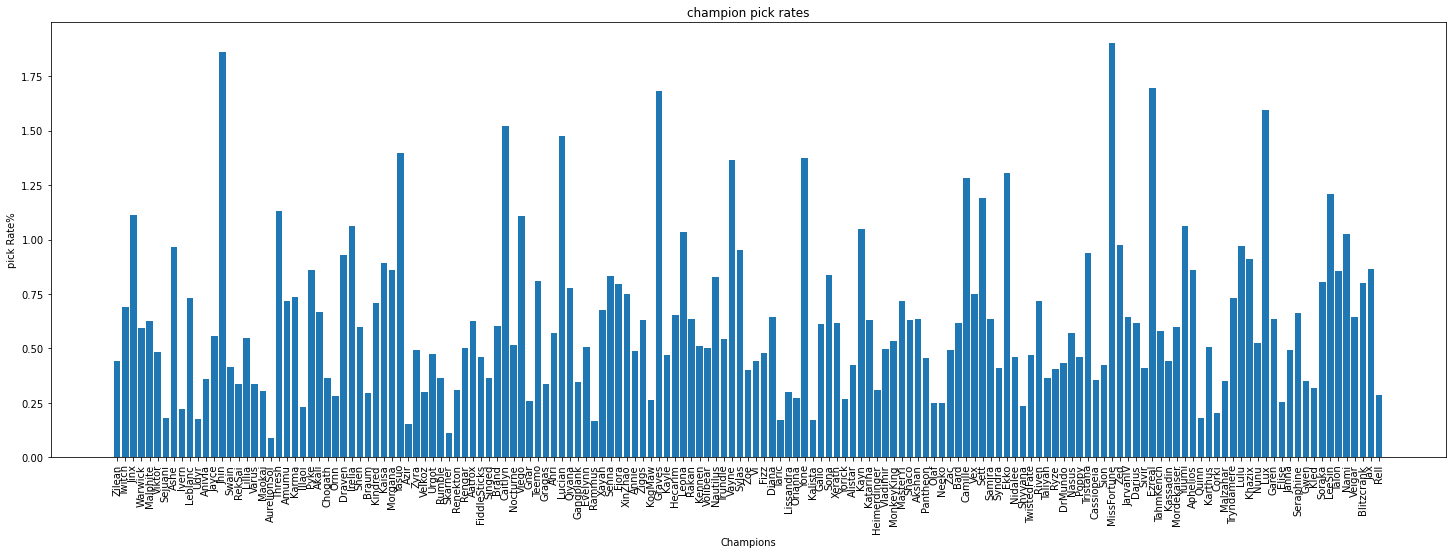

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(25,8))
plt.bar(champs, pick_rate)
plt.xlabel("Champions")
plt.ylabel("pick Rate%")
plt.title("champion pick rates")
plt.xticks(rotation=90)
plt.show()

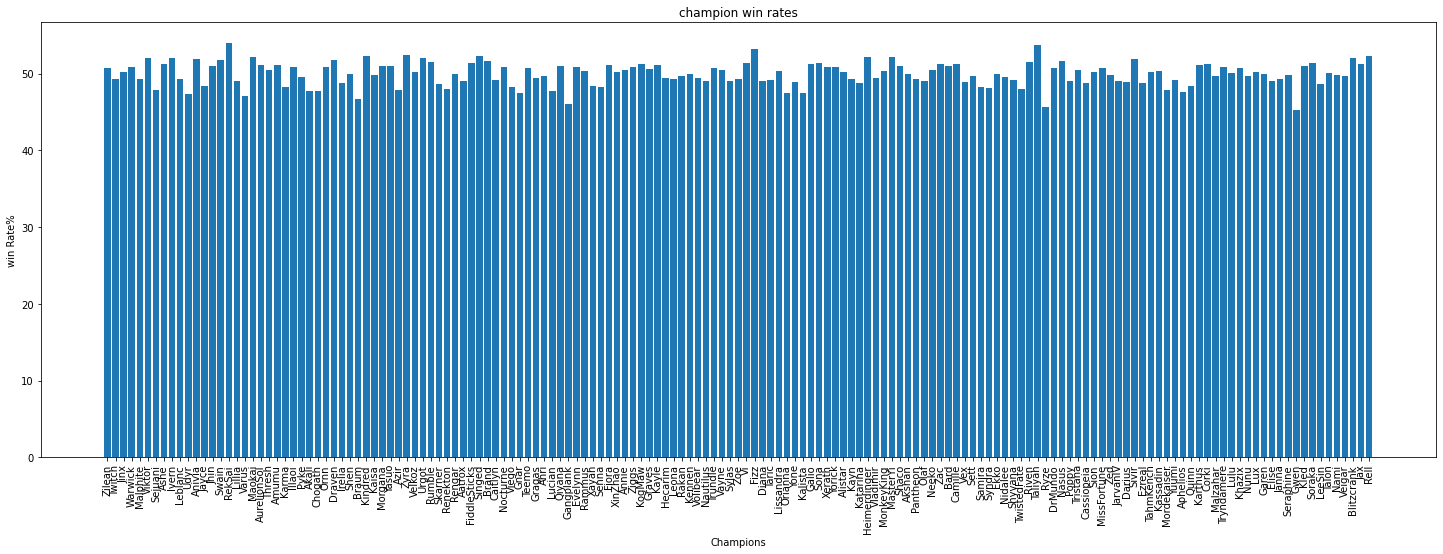

In [ ]:
%matplotlib inline
plt.figure(figsize=(25,8))
plt.bar(champs, win_rate)
plt.xlabel("Champions")
plt.ylabel("win Rate%")
plt.title("champion win rates")
plt.xticks(rotation=90)
plt.show()

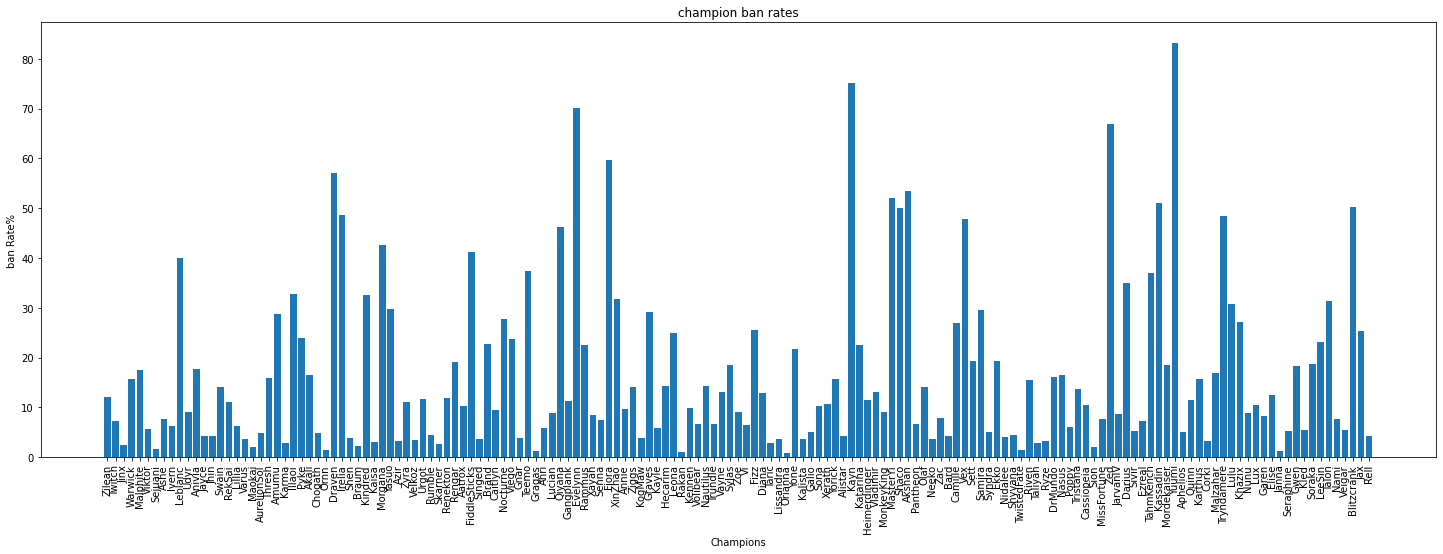

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(25,8))
plt.bar(champs, ban_rate)
plt.xlabel("Champions")
plt.ylabel("ban Rate%")
plt.title("champion ban rates")
plt.xticks(rotation=90)
plt.show()

#**Requirement 2:** Champion Synergies

We calculate the campion synergy in the following steps:


1. filter out the duo ranked participants (using the role field) in the participants dataset obtained from the previous task.

2. produce all two element combinations between participants in the same team and game

3. sum the wins of each pair.

Synergy factor is calculated as follows:

**duo_wins / duo_counts X 100%**


In [ ]:
# Add the game ids to the participants dataset
game_ids = dataset.select('gameId','participants').rdd.map(lambda x: (x[0],eval(x[1])) ).toDF(['gameId','participants']).\
            withColumn("participants", explode(col("participants"))).select('gameId').withColumn('index', monotonically_increasing_id())
            
participants_with_game_ids = game_ids.join(participants.withColumn('index', monotonically_increasing_id()), 'index', 'inner').drop('index')
participants_with_game_ids.show()

+----------+-------+----------+-----------+---------------+----------+----------+------------+-----------------+--------------------+----------------------+-----------------------+--------------------+-------------------+------+-------------------+-----------+-----------+----------------+--------------+----------------+--------------+-------------------------+--------------------+----------+---------+------------------+--------------+------------------+--------------+-----+-----+-----+-----+-----+-----+-----+--------------+-------------+-----+------+---------------------+-------------------+----------------+----------------------+----------------+---------------------------+----------------+--------------------+----------+---------+--------------+----------------+-----------------------+-------------+----------+--------------------+-------------------+------------------------------+-------------------+-----------+--------------------+-----------+----------+-------------+-------+-------

In [ ]:
participants_with_game_ids2 = participants_with_game_ids.repartition(2).cache()
participants_with_game_ids2

gameId,assists,baronKills,bountyLevel,champExperience,champLevel,championId,championName,championTransform,consumablesPurchased,damageDealtToBuildings,damageDealtToObjectives,damageDealtToTurrets,damageSelfMitigated,deaths,detectorWardsPlaced,doubleKills,dragonKills,firstBloodAssist,firstBloodKill,firstTowerAssist,firstTowerKill,gameEndedInEarlySurrender,gameEndedInSurrender,goldEarned,goldSpent,individualPosition,inhibitorKills,inhibitorTakedowns,inhibitorsLost,item0,item1,item2,item3,item4,item5,item6,itemsPurchased,killingSprees,kills,lane,largestCriticalStrike,largestKillingSpree,largestMultiKill,longestTimeSpentLiving,magicDamageDealt,magicDamageDealtToChampions,magicDamageTaken,neutralMinionsKilled,nexusKills,nexusLost,nexusTakedowns,objectivesStolen,objectivesStolenAssists,participantId,pentaKills,perks,physicalDamageDealt,physicalDamageDealtToChampions,physicalDamageTaken,profileIcon,puuid,quadraKills,riotIdName,riotIdTagline,role,sightWardsBoughtInGame,spell1Casts,spell2Casts,spell3Casts,spell4Casts,summoner1Casts,summoner1Id,summoner2Casts,summoner2Id,summonerId,summonerLevel,summonerName,teamEarlySurrendered,teamId,teamPosition,timeCCingOthers,timePlayed,totalDamageDealt,totalDamageDealtToChampions,totalDamageShieldedOnTeammates,totalDamageTaken,totalHeal,totalHealsOnTeammates,totalMinionsKilled,totalTimeCCDealt,totalTimeSpentDead,totalUnitsHealed,tripleKills,trueDamageDealt,trueDamageDealtToChampions,trueDamageTaken,turretKills,turretTakedowns,turretsLost,unrealKills,visionScore,visionWardsBoughtInGame,wardsKilled,wardsPlaced,win
4104477220,16,0,0,13396,15,80,Pantheon,0,5,1888,5220,1888,18958,12,2,2,1,true,false,false,false,false,false,13668,12100,UTILITY,0,1,0,3857,6692,3117,6676,3053,3134,3364,23,1,13,BOTTOM,581,7,3,512,1029,167,20495,12,0,0,1,0,0,10,0,"[styles ->, statP...",75497,22446,12225,3890,2mNHmA3fv18g7tqb4...,0,,,SUPPORT,0,75,38,26,2,5,4,7,14,ka-BkPwTyDff9h5iQ...,333,NARUUTOOOOOOO,false,200,UTILITY,30,1923,84538,24320,0,33858,6885,0,63,51,299,1,1,8011,1706,1137,2,3,6,0,44,2,5,15,true
4075574921,2,0,0,6097,9,517,Sylas,0,0,316,543,316,7845,6,0,1,0,false,false,false,false,false,true,5433,5085,TOP,0,0,0,6656,0,1082,2010,3158,1052,3363,11,1,3,TOP,0,2,2,536,31556,7564,7499,5,0,0,0,0,0,1,0,"[styles ->, statP...",4120,202,10562,4459,3ISnyI21Ibcc2052O...,0,,,SOLO,0,28,30,60,10,4,4,3,12,A7jDblIBvOidhqMmV...,256,Oltan,false,100,TOP,13,1212,38282,7766,0,18537,2345,0,66,164,124,1,0,2605,0,476,0,0,5,0,9,0,1,5,false
4073398222,8,0,0,6310,10,37,Sona,0,5,859,859,859,5292,2,1,0,0,false,false,false,false,false,true,4869,4455,UTILITY,0,0,0,6617,1004,3853,2055,3158,0,3364,15,0,1,NONE,0,0,1,392,5900,2413,1596,0,0,0,0,0,0,10,0,"[styles ->, statP...",2488,1046,4319,4294,cVHIzAa7yRD3ZpM61...,0,,,SUPPORT,0,35,39,51,5,3,3,3,4,q0r4TwOla6h0ZYdb1...,413,Etheryan,false,200,UTILITY,5,1193,8388,3459,1998,5915,5568,3958,3,19,28,5,0,0,0,0,0,1,1,0,34,3,3,13,true
4043262146,7,0,0,18037,17,875,Sett,0,2,8062,21485,8062,35644,6,0,1,1,false,false,false,false,false,true,13802,12900,TOP,0,1,0,3748,3111,6630,3053,3133,1029,3363,20,2,7,TOP,0,3,2,479,0,0,12596,19,0,0,0,0,0,1,0,"[styles ->, statP...",150953,11510,17797,22,mnFq5ZJGHvTz3eeHh...,0,,,SOLO,0,98,31,45,8,8,14,3,4,OyDYQGI4sjkQjQhSV...,35,Riladuobibea,false,100,TOP,18,2021,171526,17888,0,32156,3912,0,158,142,235,1,0,20573,6377,1762,4,4,4,0,14,0,0,10,true
4022670691,5,0,0,21850,18,119,Draven,0,4,767,7882,767,22758,8,2,2,0,false,false,false,false,false,true,20407,17850,BOTTOM,0,0,6,6676,6673,3006,3508,3036,3031,3363,25,5,13,BOTTOM,1365,4,3,819,0,0,4956,11,0,0,0,0,0,9,0,"[styles ->, statP...",296202,37478,28473,563,HB6Ib_rfAcxiiIHE0...,0,,,CARRY,0,111,185,21,9,6,7,5,4,fM7jixdPhwap8uNZ2...,69,xThunderstruck,false,200,BOTTOM,9,2368,309864,37808,0,36888,9419,660,300,132,281,2,2,13661,329,3458,0,0,11,0,12,2,2,11,false
4034238496,6,0,0,9961,13,234,Viego,0,2,831,30726,831,12852,1,2,0,2,false,false,false,false,false,false,8567,8250,JUNGLE,0,0,0,6632,3053,3047,1028,0,0,3364,18,1,3,JUNGLE,0,3,1,1201,1318

In [ ]:
# I'll save this DF for later use 
participants_with_game_ids.toPandas().to_csv('participants_with_game_ids.csv')

Py4JJavaError: ignored

In [ ]:

# some function definitions
def sort_tuple (x):
    '''
    sort tuple of strings alphabetically.
    '''
    return (sorted(list(x)))


def combinations(lst):
    '''
    given a list of champion names return all possible two-element combinations 
    '''
    return [sort_tuple(v) for v in itertools.combinations(lst, 2)]


sort_udf = udf(sort_tuple, ArrayType(StringType()))
combinations_udf = udf(combinations, ArrayType(ArrayType(StringType())))


In [ ]:
# filter by role=duo, then group by game and team
def remove_one_element(lst):
    if len(lst)>=2: return True
remove_single_element_lists = udf(remove_one_element, BooleanType())

duo_df = participants_with_game_ids.filter(participants_with_game_ids.role=='DUO')\
                        .select('gameId', 'teamId', 'ChampionName','role','win')\
                        .groupBy('gameId','teamId')\
                        .agg(collect_list('ChampionName'), collect_set('win'))\
                        .withColumnRenamed('collect_list(ChampionName)','ChampionName')\
                        . withColumnRenamed('collect_set(win)', 'win')

duo_df = duo_df.filter(remove_single_element_lists('championName')).cache()
duo_df.show()

In [ ]:
duo_df.printSchema()

In [ ]:
from pyspark.sql.types import *
# produce all combinations of champions in list
duo_df=duo_df.select('championName','win').withColumn('championName', combinations_udf('championName'))
duo_df.show()

In [ ]:
duo_df.printSchema()

In [ ]:
# remove the set brackets from the win column and produce a single integer
def one_element(SET):
    return int(list(SET)[0])
one_el_udf = udf(one_element, IntegerType())
duo_df = duo_df.withColumn('win', one_el_udf('win'))
duo_df.show()

In [ ]:
duo_df.printSchema()

In [ ]:
import re
"""#z= '[[1,1],[2,3],[5,6]]'

def parse_list_of_lists(z):
    z=re.sub(r"\],\[", "]|[", z)
    z=re.sub(r"\[\[", "[", z)
    z=re.sub(r'\]\]' ,"]", z).split('|')
    return [i.replace('[','').replace(']','').split(',') for i in z]

parse_udf = udf(parse_list_of_lists, ArrayType(ArrayType(StringType())))

# parse the list of lists string in champion name
duo_df =duo_df.withColumn(
    "championName",
    parse_udf('championName')
)
"""

In [ ]:
# now explode the tuples
def remove_dupes(tup):
    """filter out tuples that have the same champion """
    if tup[0] != tup[1]: return True
remove_dupes_udf = udf(remove_dupes, BooleanType())

duo_df = duo_df.withColumn('championName',explode('championName') ).\
                    filter(remove_dupes_udf('championName')).\
                    withColumn('championName',sort_udf('championName') )
                    
duo_df.show()


In [ ]:
r = duo_df.groupBy('championName').agg(sum('win')).withColumnRenamed('sum(win)','totalWins').\
        withColumnRenamed('championName','championDuos')
rr= duo_df.select('championName' ).groupBy('championName').count().\
                    withColumnRenamed('championName','championDuos')
duo_df = r.join(rr,'championDuos','outer')
duo_df.show()

In [ ]:
duo_df= duo_df.cache()

In [ ]:
# calculate synergy
duo_df = duo_df.withColumn('synergy%', round(duo_df['totalWins']*100/duo_df['count'],3))
duo_df.show()

In [ ]:
# save the output
duo_df.toPandas().to_csv(output_path+'/req_II_synergy.csv')

## Visualize

In [ ]:
import pandas as pd
df = pd.read_csv(output_path+'/req_II_synergy.csv')
df.head()

,Unnamed: 0,championDuos,totalWins,count,synergy%
0,0,"['Aatrox', 'Leblanc']",10,25,40.000
1,1,"['Ahri', 'Xerath']",1,2,50.000
2,2,"['Akali', 'Irelia']",7,16,43.750
3,3,"['Akshan', 'Ashe']",2,8,25.000
4,4,"['Alistar', 'Kayle']",1,3,33.333


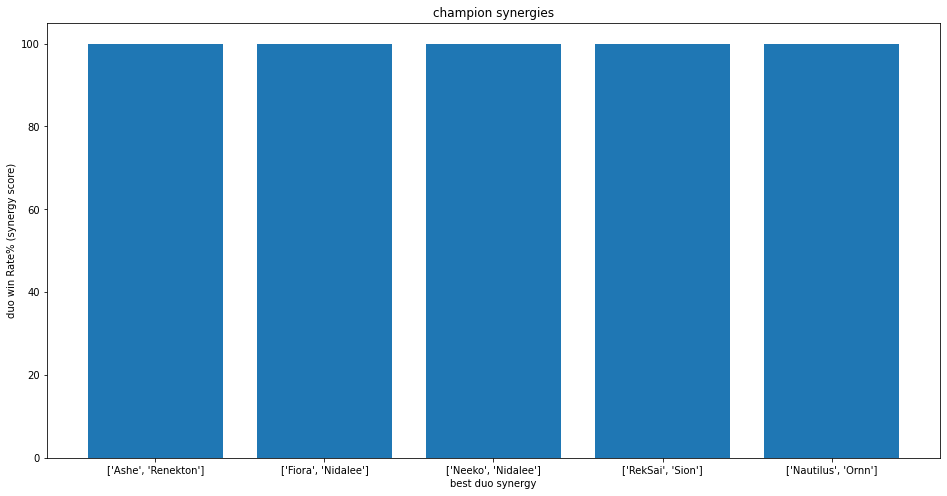

In [ ]:
# get the 5 heighest synergy pairings
import matplotlib.pyplot as plt

top5 = df.sort_values('synergy%', axis=0, ascending=False).head()
champs = list(top5['championDuos'])
syn = list(top5['synergy%'])

%matplotlib inline
plt.figure(figsize=(16,8))
plt.bar(champs, syn)
plt.xlabel("best duo synergy")
plt.ylabel("duo win Rate% (synergy score)")
plt.title("champion synergies")
#plt.xticks(rotation=90)
plt.show()

# **Requirement 3:** Item Win and Pick Rate

In [ ]:
# get the items and win win columns from the participants df from requirement 1
items_and_win = participants.select('item0', 'item1','item2','item3','item4','item5','item6', 'win') 


In [ ]:
# now combine all of the separate item columns into one column
items_and_win = items_and_win.rdd.map(lambda l: ( [l[i] for i in range(6)] , l[7])).toDF(['items', 'win'])
items_and_win.show()

+--------------------+-----+
|               items|  win|
+--------------------+-----+
|[1018, 3036, 3078...| true|
|[3157, 3152, 3020...| true|
|[3020, 3157, 1082...| true|
|[3508, 6671, 2031...| true|
|[3158, 4005, 3011...| true|
|[1054, 3078, 3047...|false|
|[6655, 3102, 4628...|false|
|[1018, 2031, 3142...|false|
|[1055, 0, 6673, 3...|false|
|[1026, 3853, 3020...|false|
|[1054, 2031, 3047...|false|
|[3053, 6630, 3067...|false|
|[6671, 6675, 3086...|false|
|[2422, 3142, 6694...|false|
|[3158, 2055, 1029...|false|
|[3091, 3047, 6632...| true|
|[6630, 3026, 3133...| true|
|[3157, 6656, 4628...| true|
|[3095, 6676, 6671...| true|
|[4005, 3853, 3157...| true|
+--------------------+-----+
only showing top 20 rows



In [ ]:
items_and_win.printSchema()

root
 |-- items: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- win: boolean (nullable = true)



In [ ]:
# then we explode
items_and_win = items_and_win.withColumn('items', explode('items'))
items_and_win.show()

+-----+----+
|items| win|
+-----+----+
| 1018|true|
| 3036|true|
| 3078|true|
|    0|true|
| 3123|true|
| 3047|true|
| 3157|true|
| 3152|true|
| 3020|true|
| 2055|true|
|    0|true|
| 1082|true|
| 3020|true|
| 3157|true|
| 1082|true|
| 4636|true|
| 3089|true|
|    0|true|
| 3508|true|
| 6671|true|
+-----+----+
only showing top 20 rows



In [ ]:
num_items_total = items_and_win.count()


In [ ]:
# now find the pickrate by counting distinct items and aggregating the win
items_and_win = items_and_win.cache()

In [ ]:
to_int = udf(lambda l:int(l), IntegerType()) # convert bool to int
items_and_win =  items_and_win.withColumn('win', to_int('win'))
r = items_and_win.groupBy('items').agg(sum('win')).withColumnRenamed('sum(win)', 'win')
rr=  items_and_win.groupBy('items').count()
items_and_win = r.join(rr, 'items', 'outer')
items_and_win.show()

+-----+------+------+
|items|   win| count|
+-----+------+------+
| 3091| 13652| 23480|
| 3009| 14137| 27385|
| 3155|   886|  1828|
| 6675|  1820|  3235|
| 3051|  2670|  5896|
| 6693|  5800| 11166|
|    0|225451|516852|
| 6664|  2022|  3891|
| 1055| 44597| 91965|
| 1042|  7253| 17337|
| 2403|    50|   170|
| 7010|    23|    42|
| 3158| 71353|138534|
| 6676| 26738| 47281|
| 3024|  2707|  5035|
| 4636|  5142| 10099|
| 3854|   156|   440|
| 2033| 15452| 32244|
| 3031| 26374| 44412|
| 3102|  4793|  8258|
+-----+------+------+
only showing top 20 rows



In [ ]:
df =  items_and_win.withColumn('pickRate', round(items_and_win['count']*100/num_items_total,3)).\
        withColumn('winRate', round(items_and_win['win']*100/items_and_win['count'],3))
df.show()

+-----+------+------+--------+-------+
|items|   win| count|pickRate|winRate|
+-----+------+------+--------+-------+
| 3091| 13652| 23480|   0.522| 58.143|
| 3009| 14137| 27385|   0.609| 51.623|
| 3155|   886|  1828|   0.041| 48.468|
| 6675|  1820|  3235|   0.072|  56.26|
| 3051|  2670|  5896|   0.131| 45.285|
| 6693|  5800| 11166|   0.248| 51.943|
|    0|225451|516852|  11.487|  43.62|
| 6664|  2022|  3891|   0.086| 51.966|
| 1055| 44597| 91965|   2.044| 48.493|
| 1042|  7253| 17337|   0.385| 41.835|
| 2403|    50|   170|   0.004| 29.412|
| 7010|    23|    42|   0.001| 54.762|
| 3158| 71353|138534|   3.079| 51.506|
| 6676| 26738| 47281|   1.051| 56.551|
| 3024|  2707|  5035|   0.112| 53.764|
| 4636|  5142| 10099|   0.224| 50.916|
| 3854|   156|   440|    0.01| 35.455|
| 2033| 15452| 32244|   0.717| 47.922|
| 3031| 26374| 44412|   0.987| 59.385|
| 3102|  4793|  8258|   0.184| 58.041|
+-----+------+------+--------+-------+
only showing top 20 rows



In [ ]:
df.toPandas().to_csv(output_path +'/req_III_itemRates.csv')

## Visualize

In [ ]:
import numpy as np
data = np.genfromtxt(output_path+'/req_III_itemRates.csv', delimiter= ",", skip_header = 1, usecols = (0,4,5),
                     converters = {1: lambda s: str(s.decode('UTF-8') or 'None')})
items = [str(int(x[0])) for x in data] 
pick_rate = [x[1] for x in data] 
win_rate = [x[2] for x in data] 


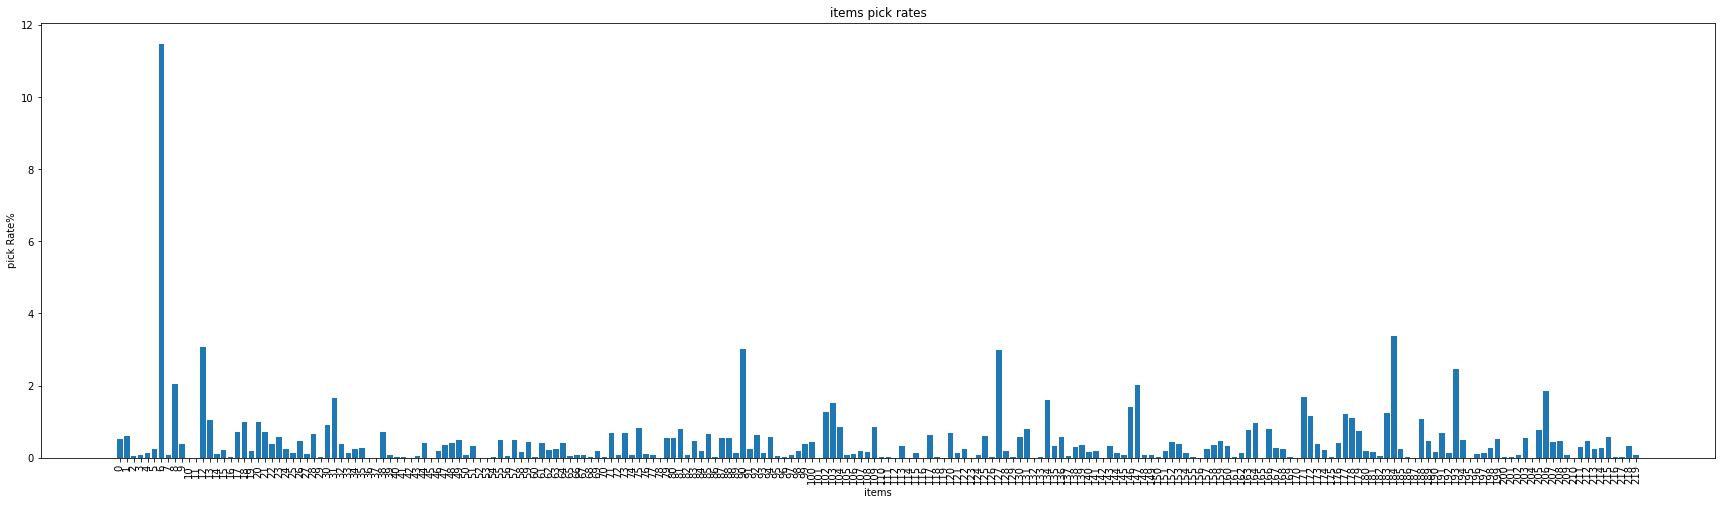

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(30,8))
plt.bar(items, pick_rate)
plt.xlabel("items")
plt.ylabel("pick Rate%")
plt.title("items pick rates")
plt.xticks(rotation=90)
plt.show()

#**Requirement 4:** Item Synergy

# **Extra Requirements**


##1. Game Duration Distribution

In [ ]:
3.6e+6

3600000.0

In [ ]:
#convert time from ms to minute
game_len= dataset[['gameDuration']]
game_len =game_len.withColumn('gameDuration',round( game_len['gameDuration']/60000, 2))

game_len.show()

+------------+
|gameDuration|
+------------+
|        0.02|
|        0.03|
|        0.02|
|       15.43|
|        0.02|
|       24.72|
|        0.02|
|        0.02|
|        0.03|
|       23.82|
|        0.03|
|        0.02|
|        0.04|
|       20.73|
|        0.04|
|        0.03|
|        0.02|
|        0.02|
|        0.02|
|        0.02|
+------------+
only showing top 20 rows



In [ ]:
game_len_df = game_len.toPandas()

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f3c57d8f4d0>]],
      dtype=object)

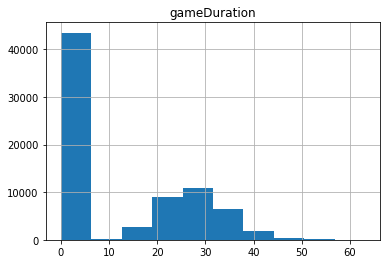

In [ ]:
%matplotlib inline
game_len_df.hist()

## 2. Best Lane For Each Champion

In [ ]:
champs_lanes = participants.select('championName', 'lane','win').cache()
champs_lanes.show()

+------------+------+-----+
|championName|  lane|  win|
+------------+------+-----+
|   Gangplank|   TOP| true|
|FiddleSticks|JUNGLE| true|
|      Rumble|MIDDLE| true|
|      Lucian|BOTTOM| true|
|        Nami|BOTTOM| true|
|      Yorick|   TOP|false|
|         Lux|MIDDLE|false|
|      Graves|JUNGLE|false|
|       Vayne|BOTTOM|false|
|      Xerath|BOTTOM|false|
| Mordekaiser|   TOP|false|
|     XinZhao|JUNGLE|false|
|  Tryndamere|MIDDLE|false|
| MissFortune|BOTTOM|false|
|       Rakan|BOTTOM|false|
|         Jax|JUNGLE| true|
|      LeeSin|JUNGLE| true|
|         Vex|MIDDLE| true|
|     Caitlyn|BOTTOM| true|
|     Morgana|BOTTOM| true|
+------------+------+-----+
only showing top 20 rows



In [ ]:
# combine champ and lane in tuple and convert win bool to int
champs_lanes = champs_lanes.rdd.map(lambda x: ( [x[0],x[1]], int(x[2]) ) ).toDF(['championLane','win'])
champs_lanes.show()


+--------------------+---+
|        championLane|win|
+--------------------+---+
|    [Gangplank, TOP]|  1|
|[FiddleSticks, JU...|  1|
|    [Rumble, MIDDLE]|  1|
|    [Lucian, BOTTOM]|  1|
|      [Nami, BOTTOM]|  1|
|       [Yorick, TOP]|  0|
|       [Lux, MIDDLE]|  0|
|    [Graves, JUNGLE]|  0|
|     [Vayne, BOTTOM]|  0|
|    [Xerath, BOTTOM]|  0|
|  [Mordekaiser, TOP]|  0|
|   [XinZhao, JUNGLE]|  0|
|[Tryndamere, MIDDLE]|  0|
|[MissFortune, BOT...|  0|
|     [Rakan, BOTTOM]|  0|
|       [Jax, JUNGLE]|  1|
|    [LeeSin, JUNGLE]|  1|
|       [Vex, MIDDLE]|  1|
|   [Caitlyn, BOTTOM]|  1|
|   [Morgana, BOTTOM]|  1|
+--------------------+---+
only showing top 20 rows



In [ ]:
#now group by the jungle lane pairs while aggregating the wins
y = champs_lanes.groupBy('championLane').agg(sum('win')).withColumnRenamed('sum(win)', 'win')
y.show()

+--------------------+----+
|        championLane| win|
+--------------------+----+
|        [Jhin, NONE]| 837|
|     [Amumu, MIDDLE]| 162|
|[Cassiopeia, JUNGLE]|  20|
|       [Annie, NONE]| 190|
| [FiddleSticks, TOP]|  22|
|     [JarvanIV, TOP]| 123|
|    [Viktor, MIDDLE]|1440|
|    [Syndra, MIDDLE]|1024|
|    [Thresh, JUNGLE]|  47|
|     [Kindred, NONE]| 450|
|      [Ornn, MIDDLE]|  62|
|      [Fizz, JUNGLE]|  28|
|      [Olaf, BOTTOM]|   3|
|     [Jayce, JUNGLE]| 133|
|[MissFortune, JUN...|  80|
|    [Zilean, BOTTOM]|1165|
|     [Sivir, MIDDLE]|  96|
|        [Varus, TOP]|  12|
|    [Veigar, JUNGLE]|  16|
|       [Irelia, TOP]|1920|
+--------------------+----+
only showing top 20 rows



In [ ]:
champs_lanes= champs_lanes.cache()

In [ ]:
champs_lanes = champs_lanes.rdd.map(lambda x: ( x[0][0],x[0][1], x[1] )).toDF(['champion','lane','win' ])

In [ ]:
champs_lanes.show()

+------------+------+---+
|    champion|  lane|win|
+------------+------+---+
|   Gangplank|   TOP|  1|
|FiddleSticks|JUNGLE|  1|
|      Rumble|MIDDLE|  1|
|      Lucian|BOTTOM|  1|
|        Nami|BOTTOM|  1|
|      Yorick|   TOP|  0|
|         Lux|MIDDLE|  0|
|      Graves|JUNGLE|  0|
|       Vayne|BOTTOM|  0|
|      Xerath|BOTTOM|  0|
| Mordekaiser|   TOP|  0|
|     XinZhao|JUNGLE|  0|
|  Tryndamere|MIDDLE|  0|
| MissFortune|BOTTOM|  0|
|       Rakan|BOTTOM|  0|
|         Jax|JUNGLE|  1|
|      LeeSin|JUNGLE|  1|
|         Vex|MIDDLE|  1|
|     Caitlyn|BOTTOM|  1|
|     Morgana|BOTTOM|  1|
+------------+------+---+
only showing top 20 rows



In [ ]:
#filter out the none lanes
def remove_none(s):
    if s !='NONE':
        return True
f = udf(remove_none, BooleanType())

champs_lanes= champs_lanes.filter(f('lane')).groupBy('champion').agg(collect_list('lane'),collect_list('win')).\
                        withColumnRenamed('collect_list(lane)', 'lane').withColumnRenamed('collect_list(win)', 'win')
                        
champs_lanes.show()


+-----------+--------------------+--------------------+
|   champion|                lane|                 win|
+-----------+--------------------+--------------------+
|     RekSai|[JUNGLE, JUNGLE, ...|[1, 1, 1, 1, 0, 1...|
|  Gangplank|[MIDDLE, TOP, JUN...|[0, 0, 1, 1, 0, 0...|
|    Kalista|[BOTTOM, BOTTOM, ...|[1, 0, 1, 0, 1, 1...|
|       Rell|[BOTTOM, BOTTOM, ...|[0, 0, 0, 0, 0, 1...|
|       Ahri|[MIDDLE, MIDDLE, ...|[1, 0, 0, 1, 0, 0...|
|       Bard|[BOTTOM, BOTTOM, ...|[1, 0, 1, 1, 0, 0...|
|   Pantheon|[BOTTOM, BOTTOM, ...|[0, 1, 0, 1, 1, 0...|
|      Poppy|[TOP, JUNGLE, TOP...|[0, 1, 1, 1, 0, 1...|
|   Katarina|[MIDDLE, MIDDLE, ...|[1, 1, 0, 1, 1, 0...|
|      Elise|[JUNGLE, JUNGLE, ...|[0, 1, 1, 0, 1, 0...|
|     Lucian|[BOTTOM, BOTTOM, ...|[0, 1, 0, 0, 0, 0...|
|      Urgot|[TOP, JUNGLE, TOP...|[0, 1, 1, 1, 0, 0...|
|MissFortune|[BOTTOM, BOTTOM, ...|[0, 1, 1, 0, 1, 0...|
|   Nautilus|[BOTTOM, BOTTOM, ...|[0, 1, 0, 0, 1, 1...|
|         Vi|[JUNGLE, JUNGLE, ...|[0, 1, 1, 1, 0

In [ ]:
# now return the most winning lane of each champion 
champs_lanes = champs_lanes.rdd.map(lambda x:   (x[0],x[1][ x[2].index(np.max(x[2]))])     ).toDF(['champion', 'mostWinningLane'])
champs_lanes.show()

+-----------+---------------+
|   champion|mostWinningLane|
+-----------+---------------+
|     RekSai|         JUNGLE|
|  Gangplank|         JUNGLE|
|    Kalista|         BOTTOM|
|       Rell|         BOTTOM|
|       Ahri|         MIDDLE|
|       Bard|         BOTTOM|
|   Pantheon|         BOTTOM|
|      Poppy|         JUNGLE|
|   Katarina|         MIDDLE|
|      Elise|         JUNGLE|
|     Lucian|         BOTTOM|
|      Urgot|         JUNGLE|
|MissFortune|         BOTTOM|
|   Nautilus|         BOTTOM|
|         Vi|         JUNGLE|
|       Azir|         MIDDLE|
|    Camille|            TOP|
|     Illaoi|            TOP|
|      Jayce|         MIDDLE|
|       Pyke|         MIDDLE|
+-----------+---------------+
only showing top 20 rows



In [ ]:
champs_lanes.toPandas().to_csv(output_path+'/req_extra_best_lanes_per_champ.csv')

In [ ]:
champs = list(champs_lanes[['champion']].rdd.map(lambda x: x[0]).collect())
lanes = list(champs_lanes[['mostWinningLane']].rdd.map(lambda x: x[0]).collect())

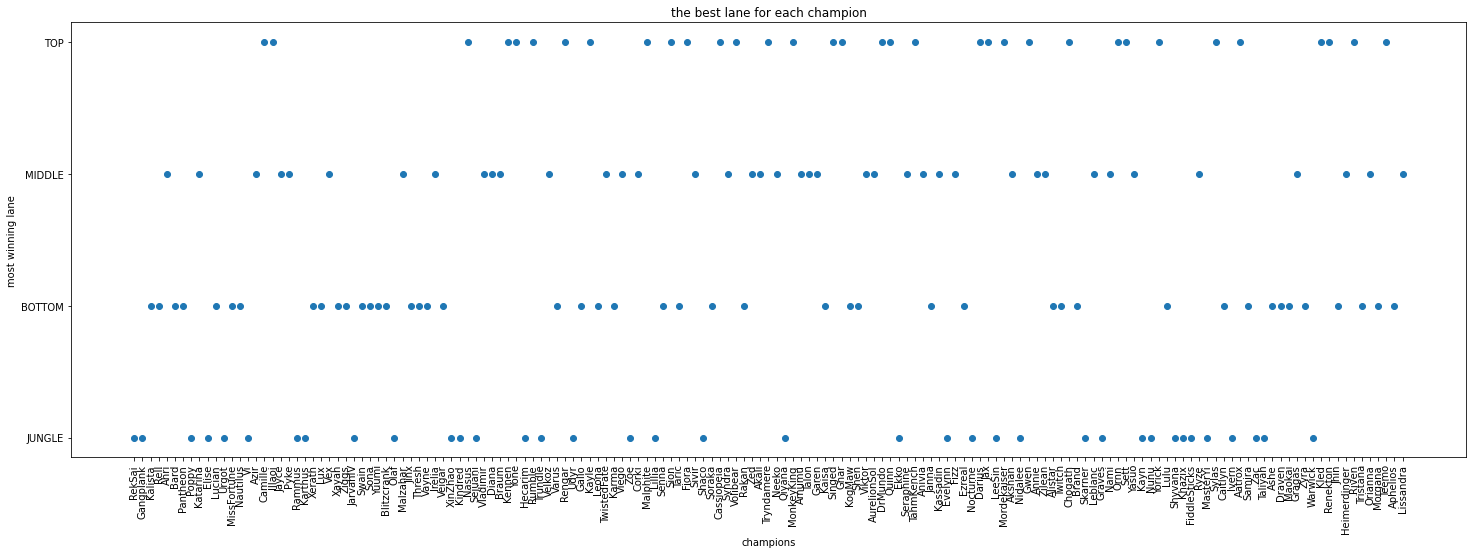

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(25,8))
plt.scatter(champs, lanes)
plt.xlabel("champions")
plt.ylabel("most winning lane")
plt.title("the best lane for each champion")
plt.xticks(rotation=90)
plt.show()